#Loading the Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
import os
from PIL import Image, ImageEnhance

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.utils import shuffle


In [20]:
os.listdir("/content/drive/MyDrive")

['Classroom',
 'Colab Notebooks',
 'Accredian.ipynb',
 'Alok_Gupta_Data_Science_L3.pdf',
 'Alok_Gupta_Resume (4).pdf',
 'Alok_Gupta_Resume (3).pdf',
 'Alok_Gupta_Resume (2).pdf',
 'Alok_Gupta_Resume (1).pdf',
 'Alok_Gupta_Resume.pdf',
 'Copy of DSA patterns Cheat Sheet.gsheet',
 'ClearSight_Minor_Project_Presentation.gslides',
 'ClearSight_Minor_Project_Synopsis (1).gdoc',
 'brain']

#Loading the Dataset

In [21]:
train_dir= "/content/drive/MyDrive/brain/Training"
test_dir= "/content/drive/MyDrive/brain/Testing"

#Load and shuffle the train data
train_paths=[]
train_labels=[]

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels= shuffle(train_paths, train_labels,random_state=42)

#Load and shuffle the test data
test_paths=[]
test_labels=[]

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels= shuffle(test_paths, test_labels,random_state=42)

In [22]:
print("No. of training images:", len(train_paths))
print("No. of testing images:", len(test_paths))


print(os.listdir(train_dir))

No. of training images: 5600
No. of testing images: 1600
['meningioma', 'notumor', 'glioma', 'pituitary']


##Class Distribution

In [23]:
from collections import Counter

train_distribution = Counter(train_labels)
test_distribution = Counter(test_labels)

print("Training Set Distribution:")
for label, count in train_distribution.items():
    print(f"{label}: {count}")

print("\nTesting Set Distribution:")
for label, count in test_distribution.items():
    print(f"{label}: {count}")

Training Set Distribution:
pituitary: 1400
notumor: 1400
glioma: 1400
meningioma: 1400

Testing Set Distribution:
glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


#EDA(Exploratory Data Analysis)

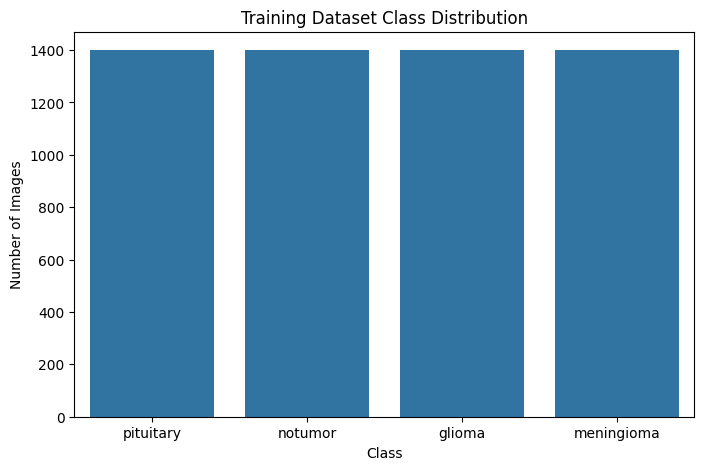

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=list(train_distribution.keys()),
    y=list(train_distribution.values())
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

##Visualizing MRI Images

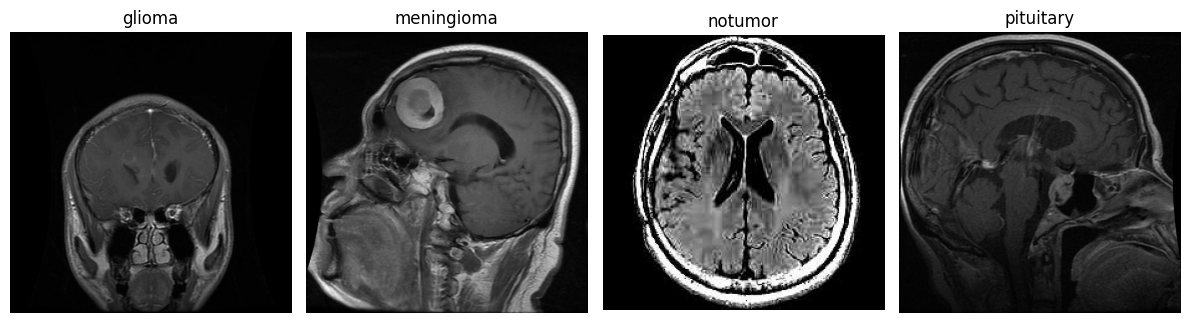

In [25]:
classes = sorted(set(train_labels))

plt.figure(figsize=(12, 4))

for i, label in enumerate(classes):

    # Find the first image belonging to this class
    index = train_labels.index(label)

    image = Image.open(train_paths[index])

    plt.subplot(1, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

##Checking the resolutions for different images

In [26]:
image_sizes = []

sample_paths = random.sample(train_paths, 80)

for path in sample_paths:
    with Image.open(path) as image:
        image_sizes.append(image.size)

In [27]:
unique_sizes = set(image_sizes)

print("Number of unique dimensions in sample:", len(unique_sizes))
print("Unique dimensions:")
print(unique_sizes)

Number of unique dimensions in sample: 18
Unique dimensions:
{(416, 512), (200, 252), (512, 512), (225, 225), (630, 630), (214, 236), (235, 216), (192, 192), (206, 244), (442, 442), (215, 234), (228, 221), (680, 680), (468, 444), (442, 454), (256, 256), (236, 236), (232, 217)}


#Image Preprocessing

In [28]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

##Creating a Training and Validation Dataset

In [29]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


##Creating the Test Dataset

In [30]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

Found 1600 files belonging to 4 classes.


In [31]:
class_names = train_dataset.class_names

print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [32]:
for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Label shape: (32,)


###Normalizing the pixel values from 0-->255  into  0-->1

In [33]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

##Prefetch

In [34]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

#Data Augmentation

Basically to introduce small variations in order to avoid overfitting

In [35]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

##Understanding the Augmentation

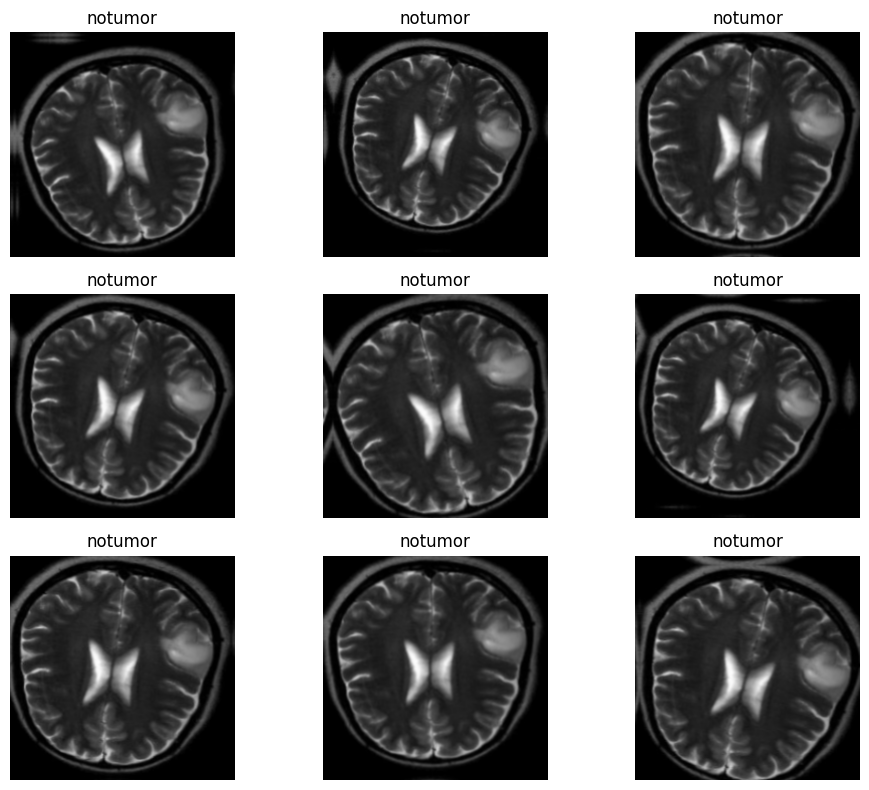

In [36]:
for images, labels in train_dataset.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

plt.figure(figsize=(10, 8))

for i in range(9):

    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )

    plt.subplot(3, 3, i + 1)
    plt.imshow(
        augmented_image[0].numpy().astype("uint8")
    )
    plt.title(class_names[sample_label])
    plt.axis("off")

plt.tight_layout()
plt.show()

###Observation:

--> Augentation is only being done on training data because validation and test data should be as natural as possible.

--> Inorder to perform on unseen data.

#Building the Architecture of CNN

In [38]:
model = Sequential()

model.add(tf.keras.Input(shape=(224, 224, 3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1./255))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(4, activation="softmax"))

In [39]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

##Compliling the Model

In [40]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

##Training the CNN

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [42]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [43]:
model_checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [44]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 505s 4s/step - accuracy: 0.5768 - loss: 0.9831 - val_accuracy: 0.7991 - val_loss: 0.5766
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.7357 - loss: 0.6793 - val_accuracy: 0.7232 - val_loss: 0.7399
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.7708 - loss: 0.5854 - val_accuracy: 0.7955 - val_loss: 0.5080
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.7770 - loss: 0.5558 - val_accuracy: 0.6107 - val_loss: 1.1456
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.7967 - loss: 0.5141 - val_accuracy: 0.8536 - val_loss: 0.3704
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.8156 - loss: 0.4729 - val_accuracy: 0.8062 - val_loss: 0.5212
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.8306 - loss: 0.4299 - val_accuracy: 0.8929 - val_loss: 0.2931
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - accuracy: 0.8364 - loss: 0.42

##Understanding the Training Results

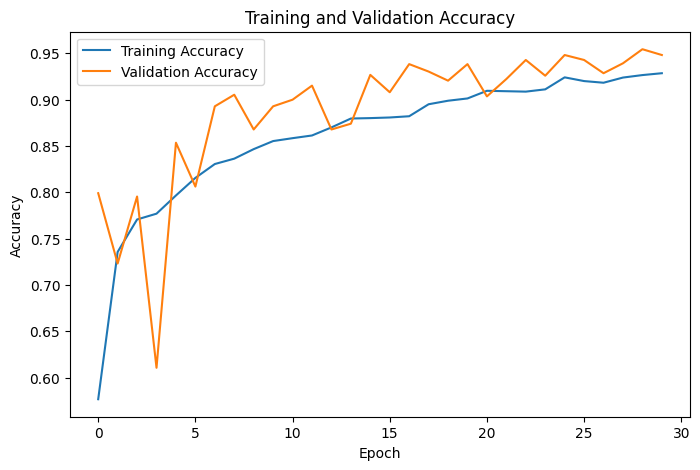

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

#Evaluating the Model

In [46]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 291s 6s/step - accuracy: 0.8594 - loss: 1.2157
Test Loss: 1.2157039642333984
Test Accuracy: 0.859375


In [47]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

##Classification Report

In [48]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.96      0.72      0.82       400
  meningioma       0.82      0.80      0.81       400
     notumor       0.76      1.00      0.87       400
   pituitary       0.95      0.92      0.93       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600



Text(0.5, 1.0, 'Confusion Matrix')

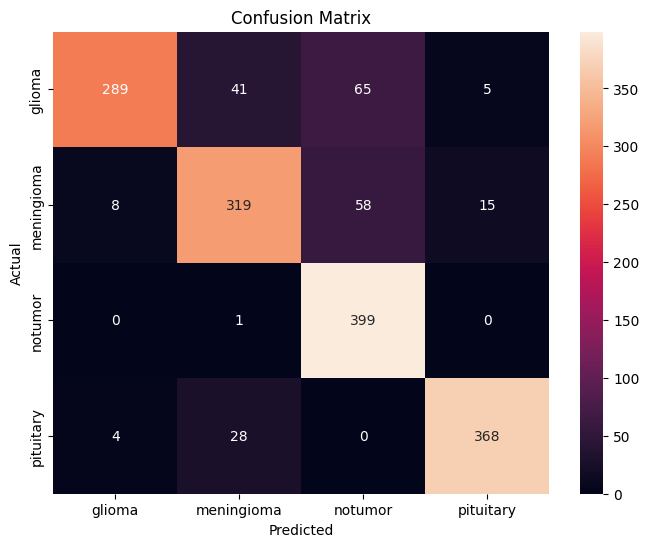

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

#Transfer Learning using VGG16

In [50]:
vgg16 = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [51]:
vgg16.trainable = False

In [52]:
model_vgg = Sequential()

model_vgg.add(vgg16)

model_vgg.add(Flatten())

model_vgg.add(Dense(128, activation="relu"))

model_vgg.add(Dropout(0.5))

model_vgg.add(Dense(4, activation="softmax"))

##Compiling the VGG16 model

In [53]:
model_vgg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

##Training the VGG16 Model

In [54]:
from tensorflow.keras.applications.vgg16 import preprocess_input

In [55]:
def preprocess_images(images, labels):
    images = preprocess_input(images)
    return images, labels



train_vgg = train_dataset.map(preprocess_images)
validation_vgg = validation_dataset.map(preprocess_images)
test_vgg = test_dataset.map(preprocess_images)


###Prefetch

In [56]:
AUTOTUNE = tf.data.AUTOTUNE

train_vgg = train_vgg.prefetch(AUTOTUNE)
validation_vgg = validation_vgg.prefetch(AUTOTUNE)
test_vgg = test_vgg.prefetch(AUTOTUNE)

In [57]:
early_stopping_vgg = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [58]:
model_checkpoint_vgg = ModelCheckpoint(
    "best_vgg16_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [59]:
history_vgg = model_vgg.fit(
    train_vgg,
    validation_data=validation_vgg,
    epochs=20,
    callbacks=[early_stopping_vgg, model_checkpoint_vgg]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 232ms/step - accuracy: 0.7069 - loss: 2.7259 - val_accuracy: 0.8339 - val_loss: 0.4132
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.7719 - loss: 0.6703 - val_accuracy: 0.8741 - val_loss: 0.3856
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 236ms/step - accuracy: 0.7839 - loss: 0.5821 - val_accuracy: 0.8429 - val_loss: 0.4409
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 245ms/step - accuracy: 0.7920 - loss: 0.6166 - val_accuracy: 0.8795 - val_loss: 0.3765
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.7917 - loss: 0.5513 - val_accuracy: 0.9000 - val_loss: 0.3000
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 232ms/step - accuracy: 0.8225 - loss: 0.4210 - val_accuracy: 0.9312 - val_loss: 0.3445
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.8230 - loss: 0.4797 - val_accuracy: 0.9321 - val_loss: 0.2263
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 279ms/step - accuracy: 0.8426 - loss: 0

##Understanding the Overall Loss and Accuracy

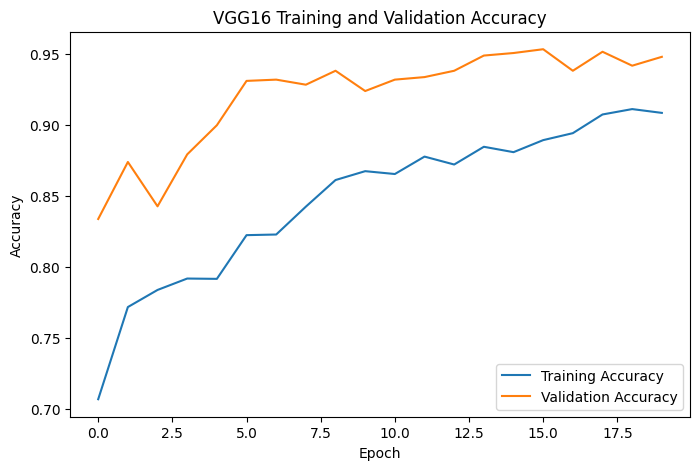

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vgg.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_vgg.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Training and Validation Accuracy")

plt.legend()
plt.show()

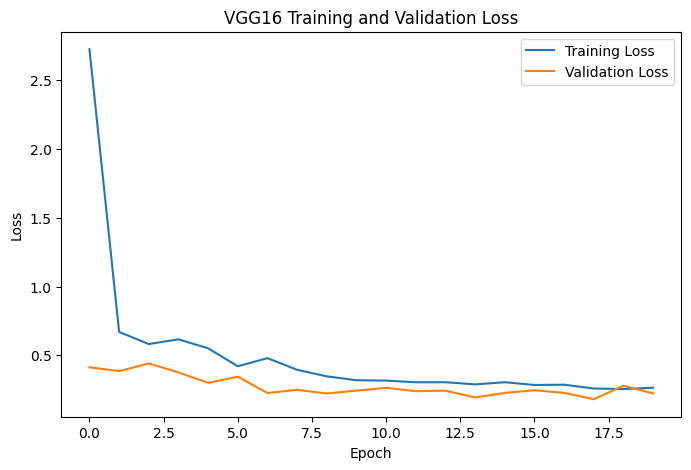

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vgg.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_vgg.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Training and Validation Loss")

plt.legend()
plt.show()

#Fine-Tuning VGG16

In [62]:
vgg16.trainable = True

In [63]:
for layer in vgg16.layers[:-4]:
    layer.trainable = False

##Recompile the model

In [64]:
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [65]:
early_stopping_ft = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [66]:
model_checkpoint_ft = ModelCheckpoint(
    "best_vgg16_finetuned.keras",
    monitor="val_loss",
    save_best_only=True
)

In [67]:
history_ft = model_vgg.fit(
    train_vgg,
    validation_data=validation_vgg,
    epochs=15,
    callbacks=[early_stopping_ft, model_checkpoint_ft]
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 272ms/step - accuracy: 0.9154 - loss: 0.2344 - val_accuracy: 0.9554 - val_loss: 0.2130
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 263ms/step - accuracy: 0.9230 - loss: 0.2028 - val_accuracy: 0.9616 - val_loss: 0.1656
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 259ms/step - accuracy: 0.9286 - loss: 0.1948 - val_accuracy: 0.9518 - val_loss: 0.2036
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 257ms/step - accuracy: 0.9359 - loss: 0.1807 - val_accuracy: 0.9536 - val_loss: 0.1886
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 263ms/step - accuracy: 0.9484 - loss: 0.1527 - val_accuracy: 0.9527 - val_loss: 0.2272
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 255ms/step - accuracy: 0.9500 - loss: 0.1531 - val_accuracy: 0.9527 - val_loss: 0.1972
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.9507 - loss: 0.1447 - val_accuracy: 0.9589 - val_loss: 0.1808


##Understanding thee Fine tuned results

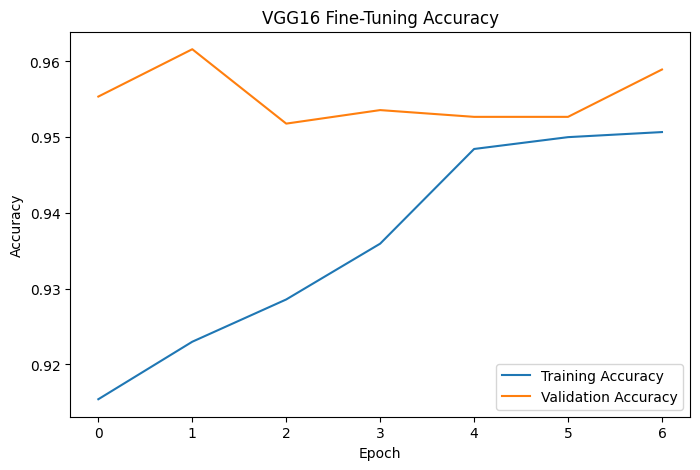

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_ft.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_ft.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Fine-Tuning Accuracy")

plt.legend()
plt.show()

#CNN vs VGG16 Comparison

In [71]:
vgg_test_loss, vgg_test_accuracy = model_vgg.evaluate(test_vgg)

print("VGG16 Test Loss:", vgg_test_loss)
print("VGG16 Test Accuracy:", vgg_test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.9044 - loss: 0.6134
VGG16 Test Loss: 0.6133594512939453
VGG16 Test Accuracy: 0.9043750166893005


In [76]:
from sklearn.metrics import classification_report

cnn_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)
y_true_vgg = []
y_pred_vgg = []

for images, labels in test_vgg:

    predictions = model_vgg.predict(images, verbose=0)

    y_true_vgg.extend(labels.numpy())
    y_pred_vgg.extend(np.argmax(predictions, axis=1))

vgg_report = classification_report(
    y_true_vgg,
    y_pred_vgg,
    target_names=class_names,
    output_dict=True
)

In [77]:
comparison = pd.DataFrame({
    "Model": ["CNN from Scratch", "VGG16"],
    "Accuracy": [
        test_accuracy,
        vgg_test_accuracy
    ],
    "Precision": [
        cnn_report["weighted avg"]["precision"],
        vgg_report["weighted avg"]["precision"]
    ],
    "Recall": [
        cnn_report["weighted avg"]["recall"],
        vgg_report["weighted avg"]["recall"]
    ],
    "F1-Score": [
        cnn_report["weighted avg"]["f1-score"],
        vgg_report["weighted avg"]["f1-score"]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN from Scratch,0.859375,0.873251,0.859375,0.858169
1,VGG16,0.904375,0.914824,0.904375,0.902475


#Testing the Model

##Individual MRI Images

In [79]:
def predict_mri(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    image_array = preprocess_input(image_array)

    prediction = model_vgg.predict(image_array, verbose=0)

    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    print("Predicted Class:", class_names[predicted_class])
    print("Confidence:", round(confidence, 2), "%")

In [83]:
def predict_mri(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    processed_image = preprocess_input(image_array)

    prediction = model_vgg.predict(
        processed_image,
        verbose=0
    )

    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Prediction: {class_names[predicted_class]}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.show()

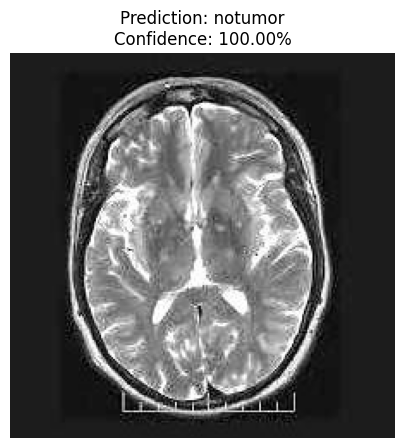

In [84]:
predict_mri(image_path)

#Saving the Model

In [91]:
save_path = "/content/drive/MyDrive/brain/brain_tumor_vgg16.keras"

model_vgg.save(save_path)

In [92]:
import json

class_path = "/content/drive/MyDrive/brain/class_names.json"

with open(class_path, "w") as file:
    json.dump(class_names, file)

In [95]:
image_path = test_paths[0]

image = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

image_array = tf.keras.utils.img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)

image_array = preprocess_input(image_array)

prediction = loaded_model.predict(
    image_array,
    verbose=0
)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

print("Prediction:", class_names[predicted_class])
print("Confidence:", round(confidence, 2), "%")

Prediction: meningioma
Confidence: 51.9 %
